In [187]:
import pandas as pd 
import numpy as np
import torch
import pickle
from sklearn.model_selection import train_test_split

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense
from tensorflow.keras.utils import to_categorical
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline

In [126]:
print(torch.__version__)          
print(torch.cuda.is_available())   
print(torch.cuda.get_device_name(0)) 

2.5.1+cu121
True
NVIDIA GeForce GTX 1050 Ti


In [16]:
import kagglehub

path = kagglehub.dataset_download("michelheusser/handwritten-digits-and-operators")

print("Path to dataset files:", path)

100%|██████████| 205M/205M [00:09<00:00, 22.6MB/s] 

Extracting files...


Path to dataset files: C:\Users\shubh\.cache\kagglehub\datasets\michelheusser\handwritten-digits-and-operators\versions\9


In [82]:
train_data = np.load('CompleteDataSet_training_tuples.npy', allow_pickle=True)
test_data = np.load('CompleteDataSet_testing_tuples.npy', allow_pickle=True)
val_data = np.load('CompleteDataSet_validation_tuples.npy', allow_pickle=True)

X_train = np.array([sample[0] for sample in train_data])
y_train = np.array([sample[1] for sample in train_data])

X_test = np.array([sample[0] for sample in test_data])
y_test = np.array([sample[1] for sample in test_data])

X_val = np.array([sample[0] for sample in val_data])
y_val = np.array([sample[1] for sample in val_data])

print("Training shapes - X:", X_train.shape, "y:", y_train.shape)
print("Testing shapes - X:", X_test.shape, "y:", y_test.shape)
print("Validation shapes - X:", X_val.shape, "y:", y_val.shape)

Training shapes - X: (200331, 28, 28) y: (200331,)
Testing shapes - X: (66778, 28, 28) y: (66778,)
Validation shapes - X: (66777, 28, 28) y: (66777,)


In [142]:
unique_classes = np.unique(y_train)  
num_classes = len(unique_classes)
label_to_index = {label: idx for idx, label in enumerate(unique_classes)}
y_train_num = np.array([label_to_index[label] for label in y_train])
y_test_num = np.array([label_to_index[label] for label in y_test])
y_val_num = np.array([label_to_index[label] for label in y_val])

In [144]:
X_train = X_train.astype(np.float32)
X_test = X_test.astype(np.float32)
X_val = X_val.astype(np.float32)

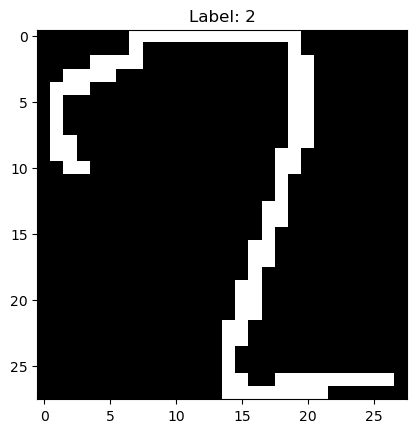

In [146]:
plt.imshow(X_train[0], cmap='gray') 
plt.title(f"Label: {y_train[0]}")
plt.show()

In [148]:
print(f"Number of samples in the dataset: {len(X_train)}")
print(f"Shape of the image 2: {X_train[0].shape}")

Number of samples in the dataset: 200331
Shape of the image 2: (28, 28)


In [150]:
num_classes = 16 

model = Sequential([
    Conv2D(filters=32, kernel_size=(3,3), activation='relu', input_shape=(28, 28, 1)),
    MaxPooling2D(pool_size=(2,2)),
    Conv2D(filters=64, kernel_size=(3,3), activation='relu'),
    MaxPooling2D(pool_size=(2,2)),
    Flatten(),
    Dense(units=128, activation='relu'),
    Dense(units=num_classes, activation='softmax')
])

model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_4 (Conv2D)               │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 16)             │         2,064 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 225,808 (882.06 KB)

 Trainable params: 225,808 (882.06 KB)

 Non-trainable params: 0 (0.00 B)

In [152]:
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

In [154]:
X_train = X_train.reshape(-1, 28, 28, 1)
X_test = X_test.reshape(-1, 28, 28, 1)
X_val = X_val.reshape(-1, 28, 28, 1)

In [161]:
history = model.fit(
    X_train, y_train_num,
    validation_split=0.2,
    epochs=10
)

Epoch 1/10
5009/5009 ━━━━━━━━━━━━━━━━━━━━ 41s 8ms/step - accuracy: 0.8617 - loss: 0.4432 - val_accuracy: 0.9528 - val_loss: 0.1424
Epoch 2/10
5009/5009 ━━━━━━━━━━━━━━━━━━━━ 39s 8ms/step - accuracy: 0.9624 - loss: 0.1100 - val_accuracy: 0.9680 - val_loss: 0.0913
Epoch 3/10
5009/5009 ━━━━━━━━━━━━━━━━━━━━ 43s 9ms/step - accuracy: 0.9737 - loss: 0.0754 - val_accuracy: 0.9677 - val_loss: 0.0952
Epoch 4/10
5009/5009 ━━━━━━━━━━━━━━━━━━━━ 41s 8ms/step - accuracy: 0.9783 - loss: 0.0602 - val_accuracy: 0.9726 - val_loss: 0.0789
Epoch 5/10
5009/5009 ━━━━━━━━━━━━━━━━━━━━ 41s 8ms/step - accuracy: 0.9817 - loss: 0.0507 - val_accuracy: 0.9743 - val_loss: 0.0772
Epoch 6/10
5009/5009 ━━━━━━━━━━━━━━━━━━━━ 41s 8ms/step - accuracy: 0.9824 - loss: 0.0473 - val_accuracy: 0.9739 - val_loss: 0.0770
Epoch 7/10
5009/5009 ━━━━━━━━━━━━━━━━━━━━ 42s 8ms/step - accuracy: 0.9840 - loss: 0.0421 - val_accuracy: 0.9745 - val_loss: 0.0753
Epoch 8/10
5009/5009 ━━━━━━━━━━━━━━━━━━━━ 45s 9ms/step - accuracy: 0.9852 - loss: 0

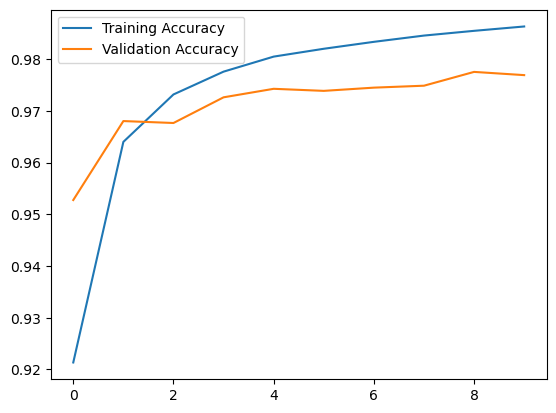

In [163]:
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.legend()
plt.show()

In [167]:
test_loss, test_accuracy = model.evaluate(X_test, y_test_num)
print(f"Test Loss: {test_loss}, Test Accuracy: {test_accuracy}")

2087/2087 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - accuracy: 0.9770 - loss: 0.0774
Test Loss: 0.07558856904506683, Test Accuracy: 0.9775075912475586


In [171]:
predictions = model.predict(X_test[:5])
predicted_labels = np.argmax(predictions, axis=1)  
print(f"Predicted Labels vs y_test: {predicted_labels, y_test_num[:5]}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
Predicted Labels vs y_test: (array([10,  8, 14, 11, 14], dtype=int64), array([10,  8, 14, 11, 14]))


2087/2087 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step


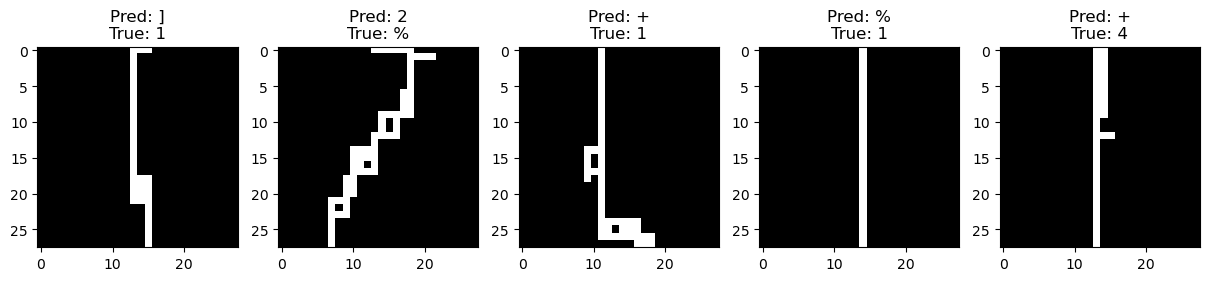

In [183]:
y_pred = model.predict(X_test).argmax(axis=1)
wrong_indices = np.where(y_pred != y_test_num)[0]

plt.figure(figsize=(15,5))
for i, idx in enumerate(wrong_indices[:5]):
    plt.subplot(1,5,i+1)
    plt.imshow(X_test[idx].reshape(28,28), cmap='gray')
    plt.title(f"Pred: {unique_classes[y_pred[idx]]}\nTrue: {unique_classes[y_test_num[idx]]}")
plt.show()

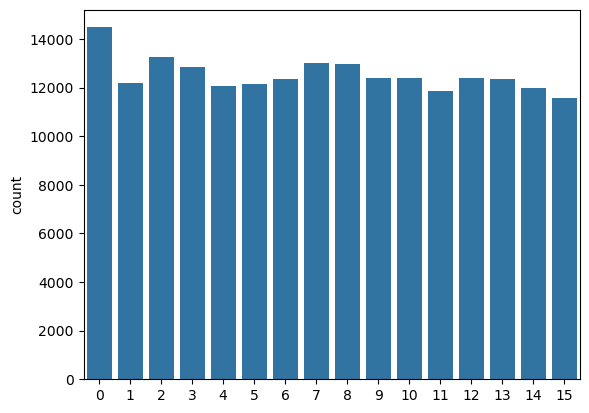

In [179]:
sns.countplot(x=y_train_num)
plt.show()

In [189]:
model.save('digit_operator_classifier.h5')
with open('label_mapping.pkl', 'wb') as f:
    pickle.dump(label_to_index, f)